# Exploratory Data Analysis — Diabetes Risk

This notebook explores the cleaned dataset to answer the business questions:
1. **Descriptive:** What share of patients in each age group and BMI category has high diabetes risk?
2. **Lifestyle factors:** Which modifiable habits show the largest difference in high-risk rates?
3. **Feature relationships:** How do features correlate with each other and the target?

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('data/diabetes_risk_cleaned.csv')
print('Shape:', df.shape)
df.head()

Shape: (15000, 19)


,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low


## 1. Target Variable Distribution

Check class balance in `diabetes_risk`.

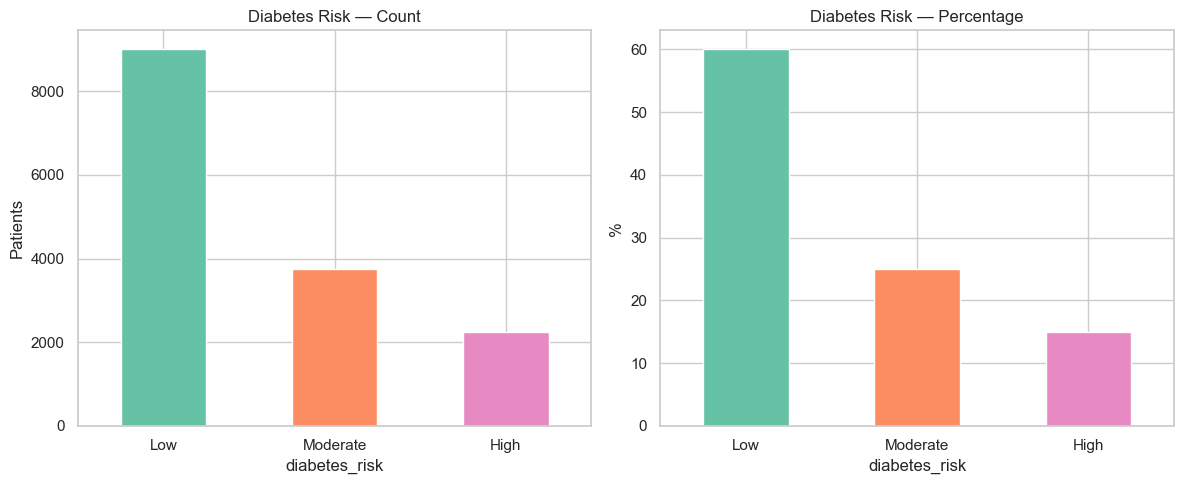

               count   pct
diabetes_risk             
Low             9000  60.0
Moderate        3750  25.0
High            2250  15.0


In [20]:
risk_counts = df['diabetes_risk'].value_counts()
risk_pct = df['diabetes_risk'].value_counts(normalize=True).mul(100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

risk_counts.plot.bar(ax=axes[0], color=['#66c2a5', '#fc8d62', '#e78ac3'])
axes[0].set_title('Diabetes Risk — Count')
axes[0].set_ylabel('Patients')
axes[0].tick_params(axis='x', rotation=0)

risk_pct.plot.bar(ax=axes[1], color=['#66c2a5', '#fc8d62', '#e78ac3'])
axes[1].set_title('Diabetes Risk — Percentage')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(pd.DataFrame({'count': risk_counts, 'pct': risk_pct}))

## 2. Risk by Age Group and BMI Category (Business Q1)

Create age and BMI bins to see which demographic groups carry the most risk.

In [21]:
# Create bins
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 40, 50, 60, 100],
                         labels=['18-30', '31-40', '41-50', '51-60', '60+'])

df['bmi_category'] = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, 100],
                            labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

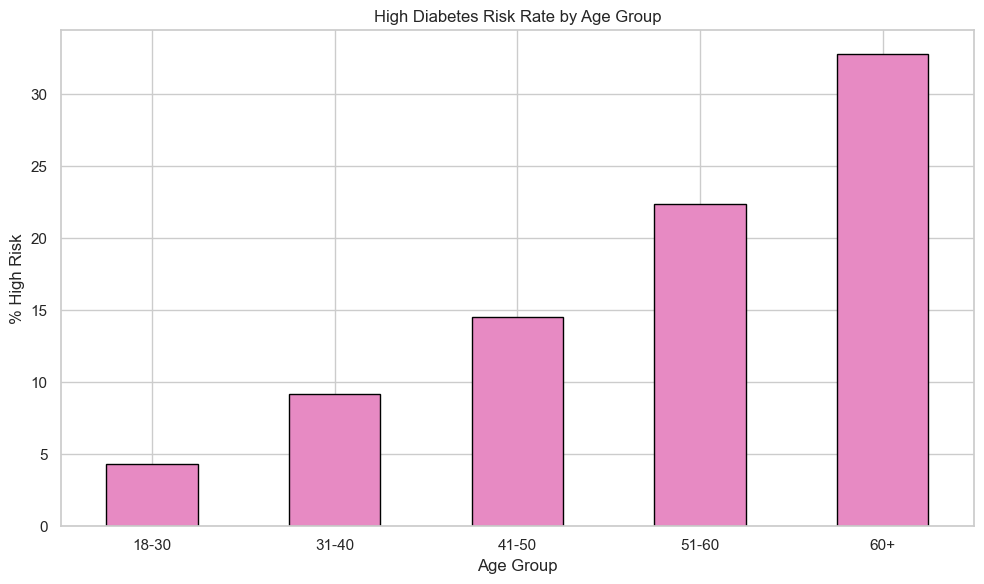

age_group
18-30     4.3
31-40     9.2
41-50    14.5
51-60    22.4
60+      32.8
Name: diabetes_risk, dtype: float64


In [22]:
# High-risk rate by age group
is_high = (df['diabetes_risk'] == 'High').astype(int)
high_by_age = is_high.groupby(df['age_group']).mean().mul(100).round(1)

high_by_age.plot.bar(color='#e78ac3', edgecolor='black')
plt.title('High Diabetes Risk Rate by Age Group')
plt.ylabel('% High Risk')
plt.xlabel('Age Group')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(high_by_age)

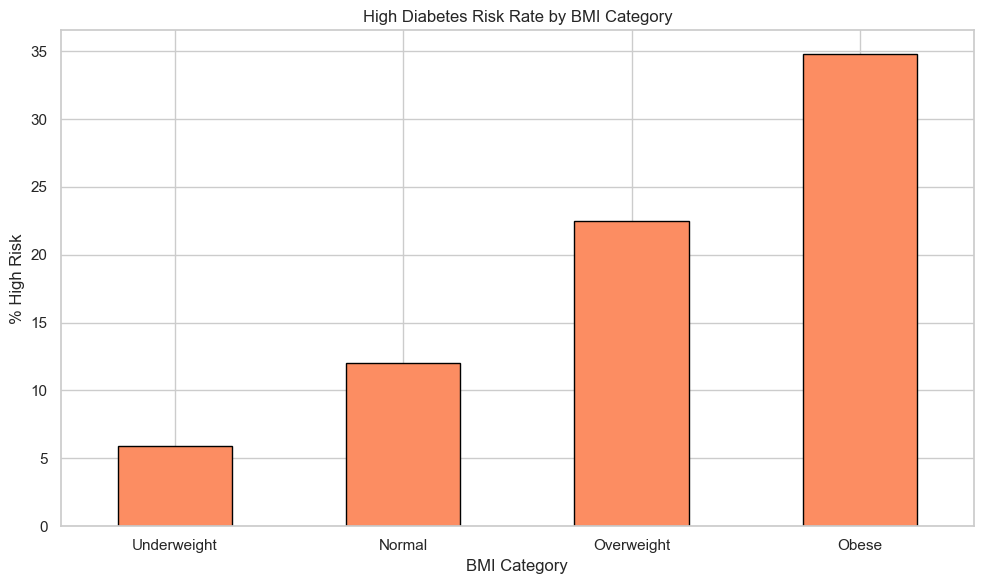

bmi_category
Underweight     5.9
Normal         12.0
Overweight     22.5
Obese          34.8
Name: diabetes_risk, dtype: float64


In [23]:
# High-risk rate by BMI category
high_by_bmi = is_high.groupby(df['bmi_category']).mean().mul(100).round(1)

high_by_bmi.plot.bar(color='#fc8d62', edgecolor='black')
plt.title('High Diabetes Risk Rate by BMI Category')
plt.ylabel('% High Risk')
plt.xlabel('BMI Category')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(high_by_bmi)

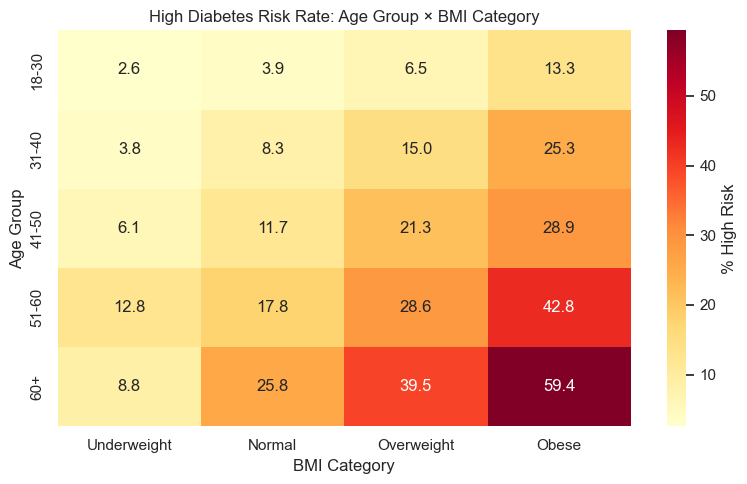

In [24]:
# Heatmap: high-risk rate by age group × BMI category
cross = is_high.groupby([df['age_group'], df['bmi_category']]).mean().mul(100).round(1).unstack()

plt.figure(figsize=(8, 5))
sns.heatmap(cross, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': '% High Risk'})
plt.title('High Diabetes Risk Rate: Age Group × BMI Category')
plt.ylabel('Age Group')
plt.xlabel('BMI Category')
plt.tight_layout()
plt.show()

## 3. Numeric Feature Distributions

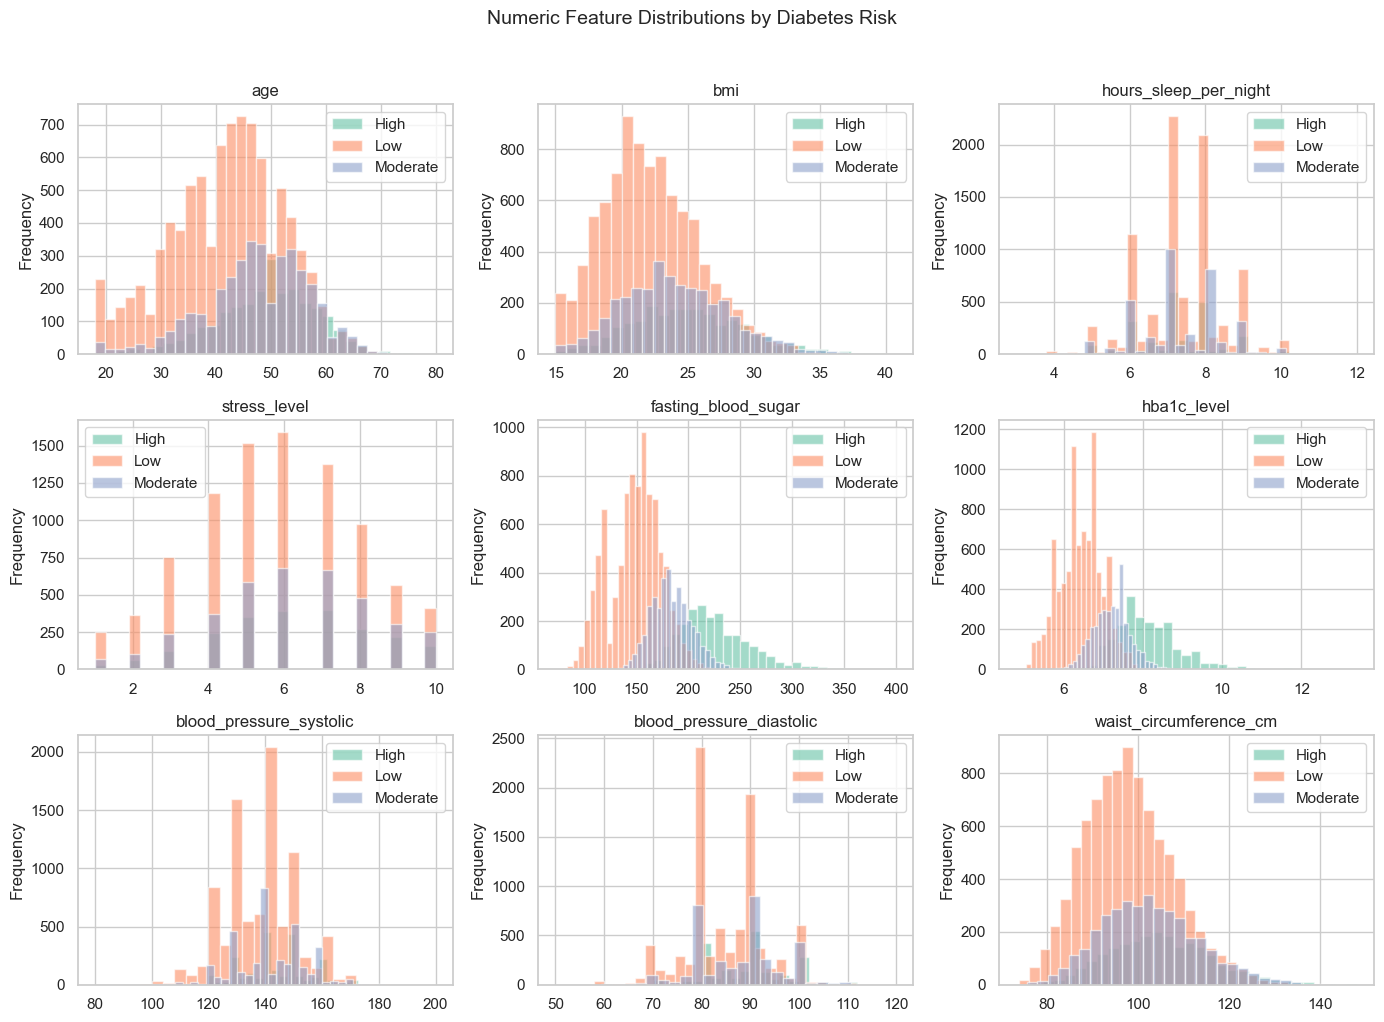

In [25]:
numeric_cols = ['age', 'bmi', 'hours_sleep_per_night', 'stress_level',
                'fasting_blood_sugar', 'hba1c_level',
                'blood_pressure_systolic', 'blood_pressure_diastolic',
                'waist_circumference_cm']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flatten(), numeric_cols):
    df.groupby('diabetes_risk')[col].plot.hist(ax=ax, alpha=0.6, bins=30, legend=True)
    ax.set_title(col)
    ax.set_xlabel('')

plt.suptitle('Numeric Feature Distributions by Diabetes Risk', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 4. Correlation Heatmap

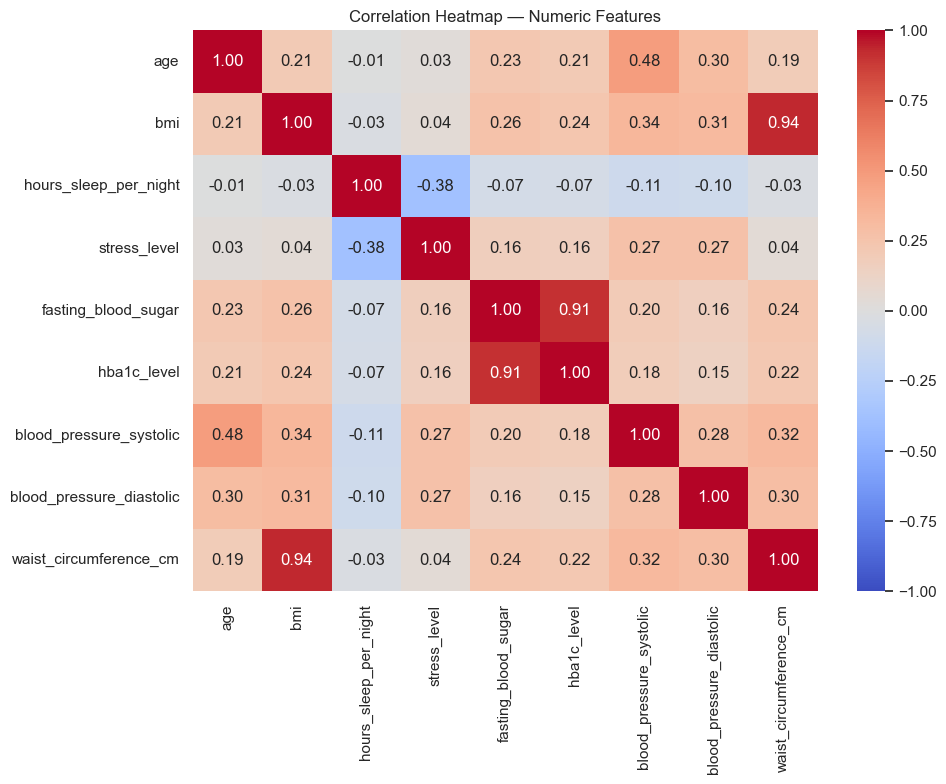

In [26]:
plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
mask = corr.where(abs(corr) >= 0.3).notna()  # highlight strong correlations
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()

## 5. Lifestyle Factors vs. Diabetes Risk (Business Q3)

Compare high-risk rates across modifiable lifestyle factors.

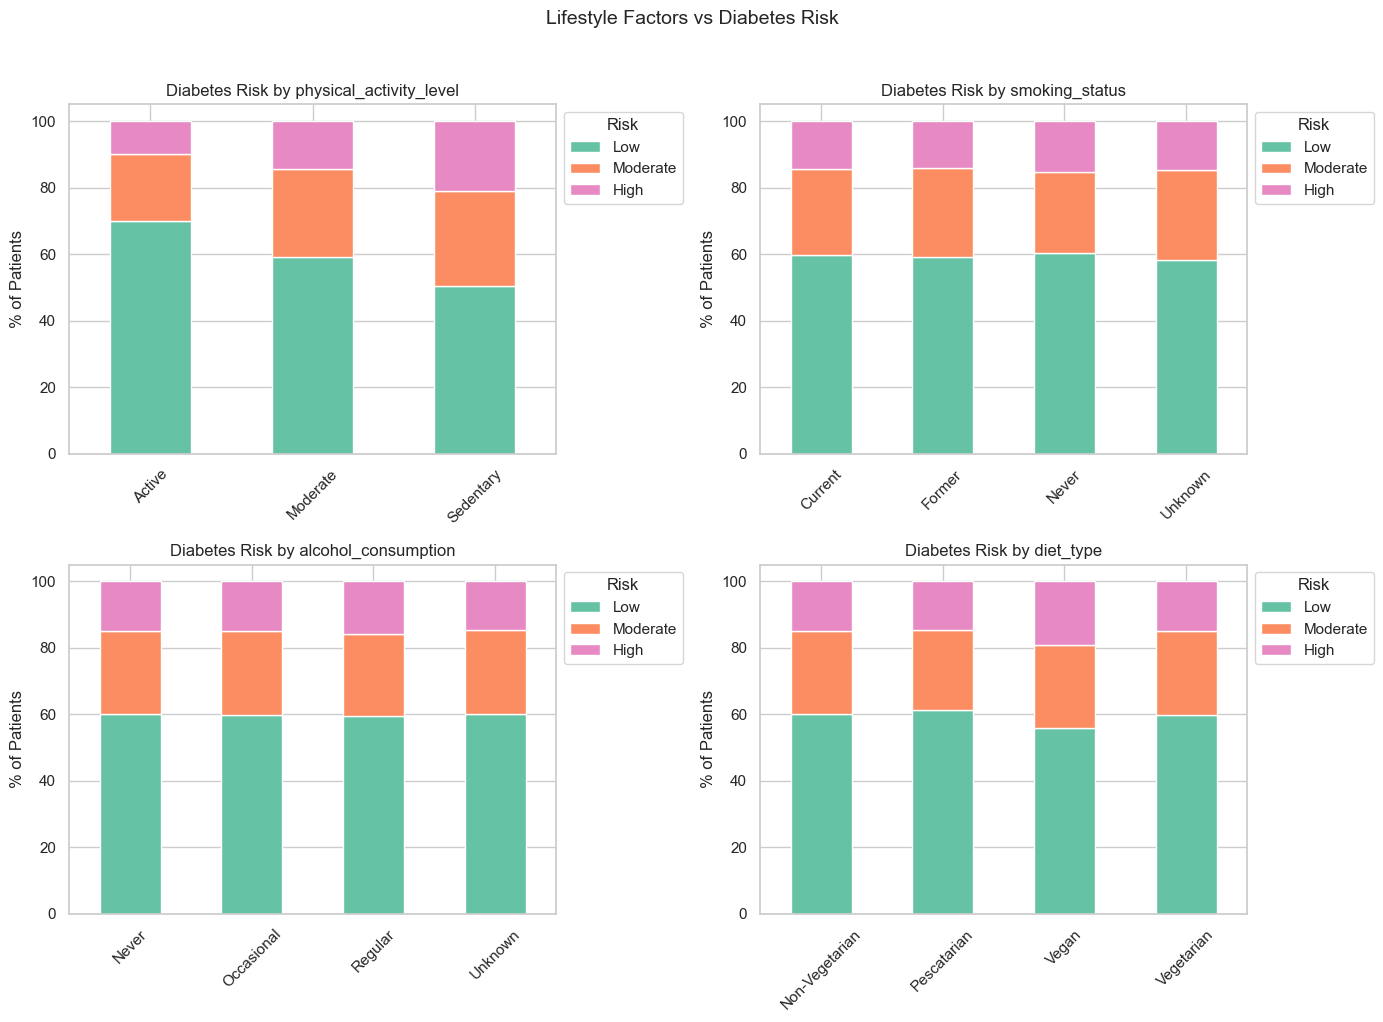

In [27]:
lifestyle_cols = ['physical_activity_level', 'smoking_status',
                  'alcohol_consumption', 'diet_type']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), lifestyle_cols):
    ct = pd.crosstab(df[col], df['diabetes_risk'], normalize='index').mul(100).round(1)
    ct = ct[['Low', 'Moderate', 'High']]  # consistent order
    ct.plot.bar(stacked=True, ax=ax, color=['#66c2a5', '#fc8d62', '#e78ac3'])
    ax.set_title(f'Diabetes Risk by {col}')
    ax.set_ylabel('% of Patients')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Risk', bbox_to_anchor=(1.0, 1.0))

plt.suptitle('Lifestyle Factors vs Diabetes Risk', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

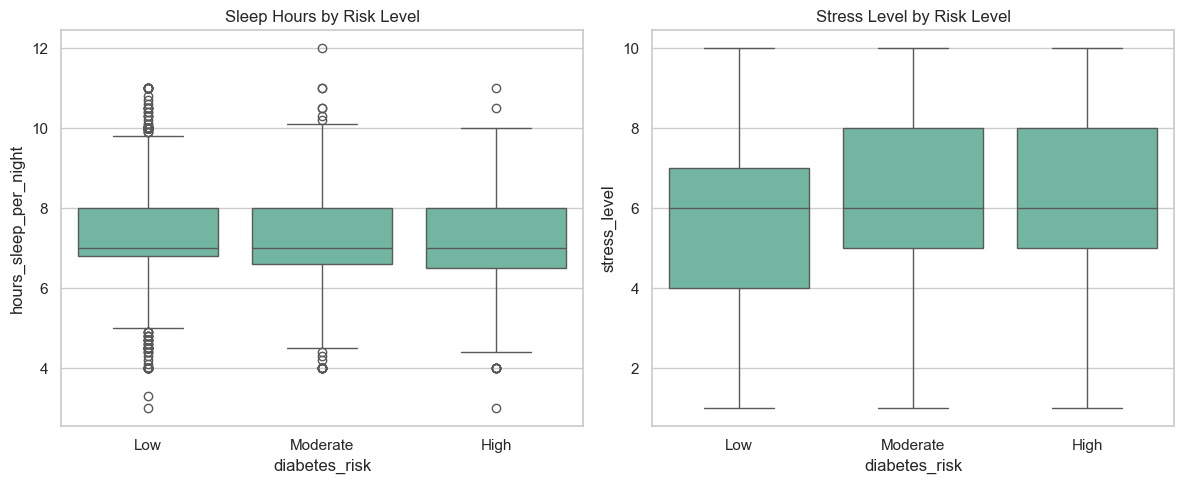

In [28]:
# Sleep and stress by risk level
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x='diabetes_risk', y='hours_sleep_per_night',
            order=['Low', 'Moderate', 'High'], ax=axes[0])
axes[0].set_title('Sleep Hours by Risk Level')

sns.boxplot(data=df, x='diabetes_risk', y='stress_level',
            order=['Low', 'Moderate', 'High'], ax=axes[1])
axes[1].set_title('Stress Level by Risk Level')

plt.tight_layout()
plt.show()

## 6. Clinical Markers vs. Risk

> ⚠️ **Leakage note:** `fasting_blood_sugar` and `hba1c_level` are diagnostic criteria for diabetes. These plots are informational — these features need careful handling during modelling.

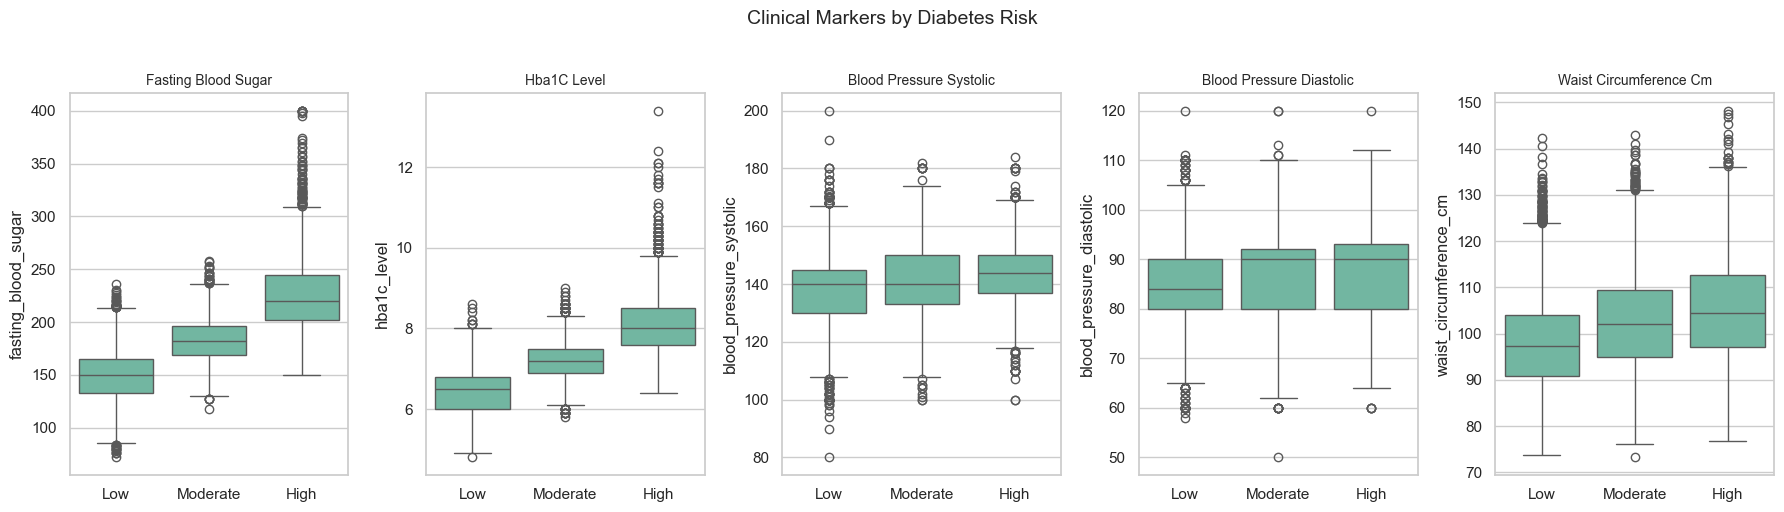

In [29]:
clinical_cols = ['fasting_blood_sugar', 'hba1c_level',
                 'blood_pressure_systolic', 'blood_pressure_diastolic',
                 'waist_circumference_cm']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, col in zip(axes, clinical_cols):
    sns.boxplot(data=df, x='diabetes_risk', y=col,
                order=['Low', 'Moderate', 'High'], ax=ax)
    ax.set_title(col.replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel('')

plt.suptitle('Clinical Markers by Diabetes Risk', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 7. Demographic Factors

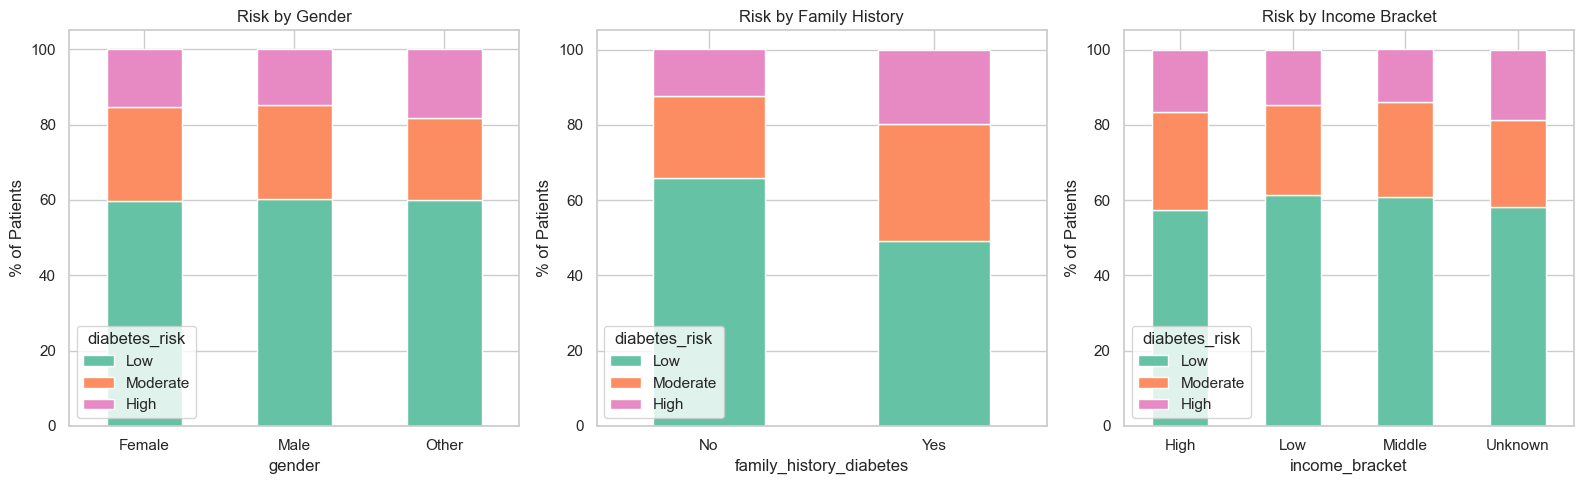

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gender
ct_gender = pd.crosstab(df['gender'], df['diabetes_risk'], normalize='index').mul(100).round(1)
ct_gender[['Low', 'Moderate', 'High']].plot.bar(stacked=True, ax=axes[0],
                                                 color=['#66c2a5', '#fc8d62', '#e78ac3'])
axes[0].set_title('Risk by Gender')
axes[0].set_ylabel('% of Patients')
axes[0].tick_params(axis='x', rotation=0)

# Family history
ct_fam = pd.crosstab(df['family_history_diabetes'], df['diabetes_risk'], normalize='index').mul(100).round(1)
ct_fam[['Low', 'Moderate', 'High']].plot.bar(stacked=True, ax=axes[1],
                                              color=['#66c2a5', '#fc8d62', '#e78ac3'])
axes[1].set_title('Risk by Family History')
axes[1].set_ylabel('% of Patients')
axes[1].tick_params(axis='x', rotation=0)

# Income bracket
ct_inc = pd.crosstab(df['income_bracket'], df['diabetes_risk'], normalize='index').mul(100).round(1)
ct_inc[['Low', 'Moderate', 'High']].plot.bar(stacked=True, ax=axes[2],
                                              color=['#66c2a5', '#fc8d62', '#e78ac3'])
axes[2].set_title('Risk by Income Bracket')
axes[2].set_ylabel('% of Patients')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 8. Key Takeaways

Summarize findings after running all cells:

- **Class balance:** Low (60%), Moderate (25%), High (15%) — imbalanced, will need handling during modelling
- **Age & BMI:** Diabetes risk increases steadily with age and BMI. Patients aged 60+ have the highest risk rate (32.8%), while those in the Obese BMI category are most at risk (34.8%) — roughly 6× and 6× higher than the youngest and leanest groups respectively.
- **Strongest lifestyle factor:** Physical activity shows the largest difference in high-risk rates among all lifestyle factors. Sedentary patients have a 21.0% high-risk rate — more than double that of active patients (9.8%) — with an 11.2 percentage-point spread, far exceeding smoking (1.1 pp) and alcohol (1.3 pp).
- **Clinical markers:** `fasting_blood_sugar` and `hba1c_level` likely show the sharpest separation (expected — they define the condition)
- **Next step:** Feature engineering and model building